In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
pcsv = pd.read_csv('python_new.csv')
rcsv = pd.read_csv('rust2.csv')


pcsv['nprobe'] = pcsv['params'].str.extract(r'nprobe=(\d+)').astype(int)
rcsv['nprobe'] = rcsv['params'].str.extract(r'nprobe=(\d+)').astype(int)

rcsv['task'] = rcsv['params'].str.extract(r'rust-lmi-task=(\w+)')
pcsv['task'] = pcsv['params'].str.extract(r't(\d+)')

/tmp/ipykernel_2922779/1996688667.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcsv_task1['memuse'] = '191GB'
/tmp/ipykernel_2922779/1996688667.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcsv_task1['memuse'] = '217GB'


Task 1 Performance Comparison: Python vs Rust
                              Python                  Rust
kmeanstime      19 minutes 2 seconds  9 minutes 38 seconds
trainmodeltime  11 minutes 3 seconds   9 minutes 9 seconds
buildtime       64 minutes 7 seconds  67 minutes 8 seconds
querytime       9 minutes 10 seconds            17 seconds
recall                      0.899552               0.89976
memuse                         191GB                 217GB


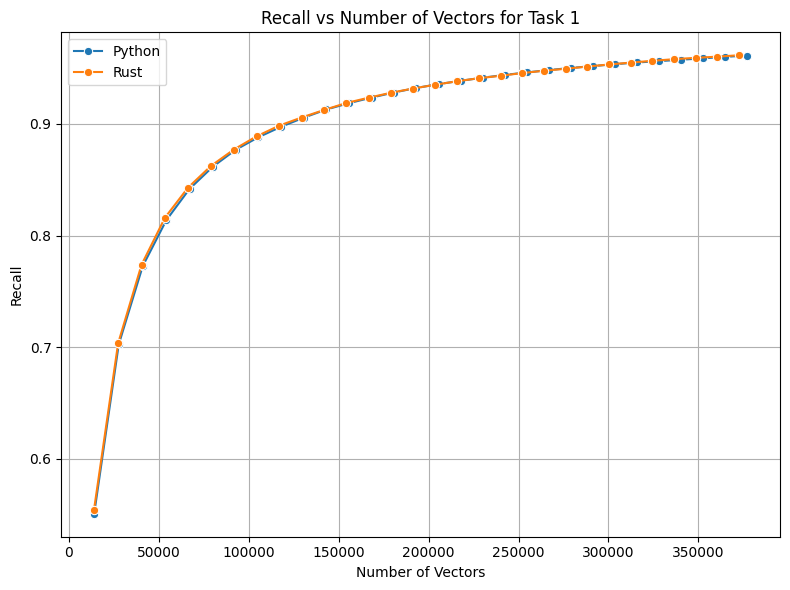

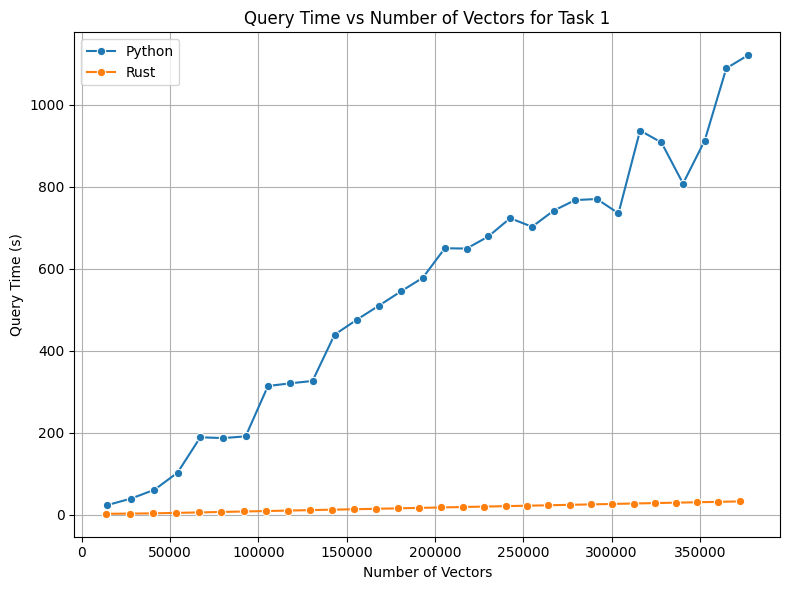

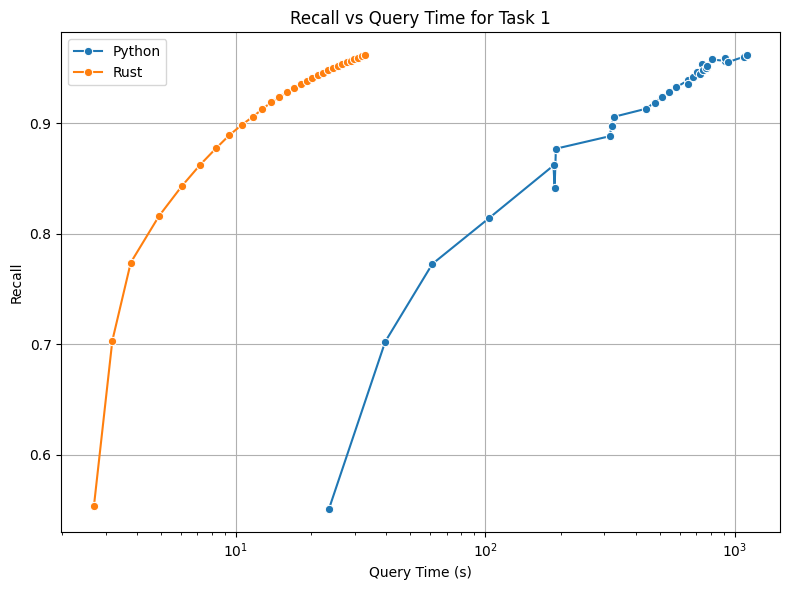

In [9]:
pcsv_task1 = pcsv[(pcsv['task'] == '1') & (pcsv['size'] == '100M')]
pcsv_task1['memuse'] = '191GB'

rcsv_task1 = rcsv[(rcsv['task'] == '1') & (rcsv['size'] == '100M')]
rcsv_task1['memuse'] = '217GB'

numeric_metrics = ['kmeanstime', 'trainmodeltime', 'buildtime', 'querytime', 'recall']
non_numeric_metrics = ['memuse']

python_means = pcsv_task1[numeric_metrics].mean()
rust_means = rcsv_task1[numeric_metrics].mean()

python_means['memuse'] = pcsv_task1['memuse'].iloc[0]
rust_means['memuse'] = rcsv_task1['memuse'].iloc[0]

# Convert time values from seconds to minutes and seconds format
for metric in ['kmeanstime', 'trainmodeltime', 'buildtime', 'querytime']:
    if metric in python_means:
        minutes = int(python_means[metric] // 60)
        seconds = int(python_means[metric] % 60)
        if minutes > 0:
            python_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            python_means[metric] = f"{seconds} seconds"
    if metric in rust_means:
        minutes = int(rust_means[metric] // 60)
        seconds = int(rust_means[metric] % 60)
        if minutes > 0:
            rust_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            rust_means[metric] = f"{seconds} seconds"

comparison_df = pd.DataFrame({
    'Python': python_means,
    'Rust': rust_means,
})

comparison_df = comparison_df.round(6)
print("Task 1 Performance Comparison: Python vs Rust")
print(comparison_df)

pcsv_task1 = pcsv[(pcsv['task'] == '1') & (pcsv['size'] == '100M')]

# Figure 1: Recall vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task1, x='nvectors', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task1, x='nvectors', y='recall', marker='o', label='Rust')
plt.title('Recall vs Number of Vectors for Task 1')
plt.xlabel('Number of Vectors')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task1_recall_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Query Time vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task1, x='nvectors', y='querytime', marker='o', label='Python')
sns.lineplot(data=rcsv_task1, x='nvectors', y='querytime', marker='o', label='Rust')
plt.title('Query Time vs Number of Vectors for Task 1')
plt.xlabel('Number of Vectors')
plt.ylabel('Query Time (s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task1_querytime_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Recall vs Query Time for Task 1
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task1, x='querytime', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task1, x='querytime', y='recall', marker='o', label='Rust')
plt.title('Recall vs Query Time for Task 1')
plt.xlabel('Query Time (s)')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig('task1_recall_vs_querytime.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2922779/1329475625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcsv_task3['memuse'] = '76GB'
/tmp/ipykernel_2922779/1329475625.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rcsv_task3['memuse'] = '88GB'


Task 3 Performance Comparison: Python vs Rust
                                Python                   Rust
kmeanstime       12 minutes 39 seconds   9 minutes 18 seconds
encdatabasetime   5 minutes 12 seconds  10 minutes 39 seconds
encqueriestime               0 seconds              0 seconds
trainmodeltime    21 minutes 9 seconds   8 minutes 55 seconds
buildtime        89 minutes 37 seconds  91 minutes 38 seconds
querytime                   53 seconds              7 seconds
recall                        0.548697                0.54729
memuse                            76GB                   88GB


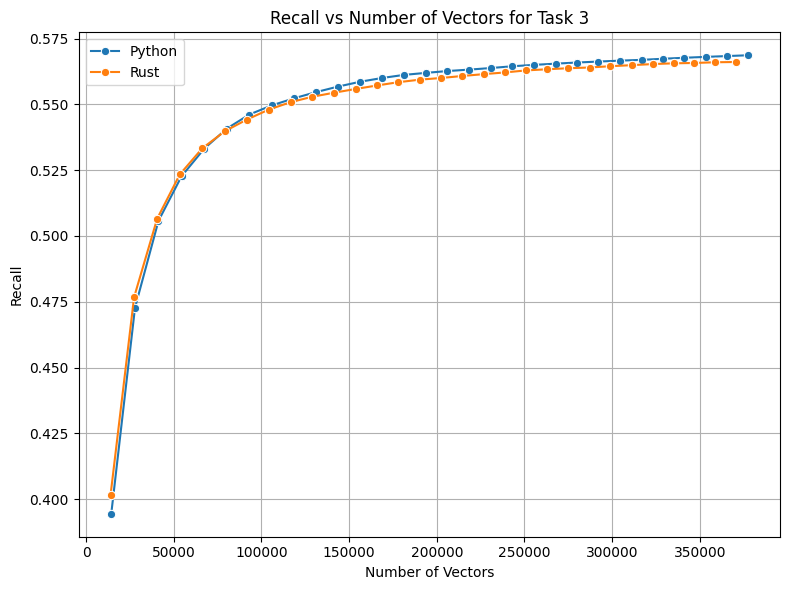

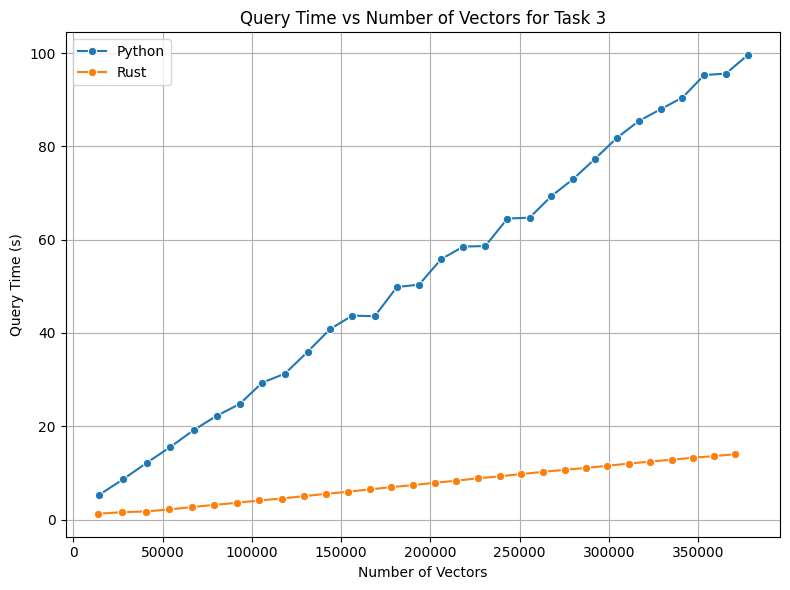

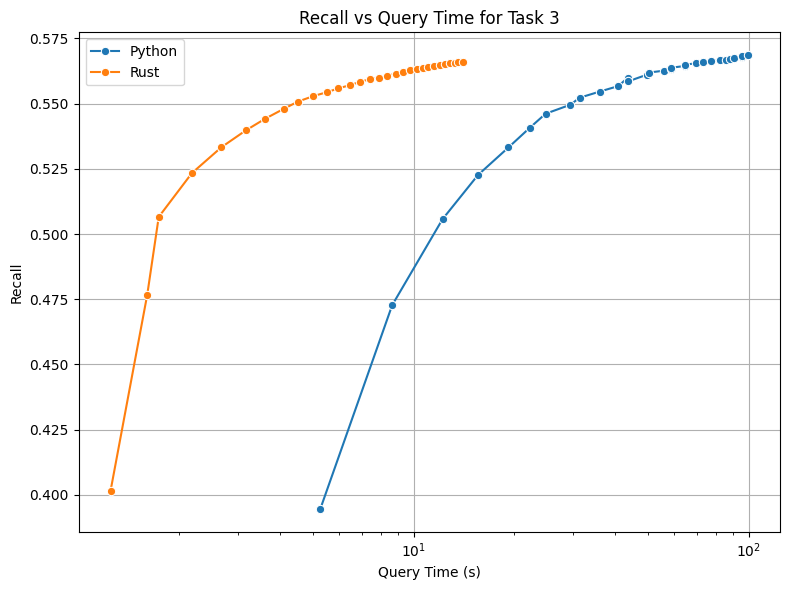

In [6]:
pcsv_task3 = pcsv[(pcsv['task'] == '3') & (pcsv['size'] == '100M')]
pcsv_task3['memuse'] = '76GB'

rcsv_task3 = rcsv[(rcsv['task'] == '3') & (rcsv['size'] == '100M')]
rcsv_task3['memuse'] = '88GB'

numeric_metrics = ['kmeanstime', 'encdatabasetime', 'encqueriestime','trainmodeltime', 'buildtime', 'querytime', 'recall']
non_numeric_metrics = ['memuse']

python_means = pcsv_task3[numeric_metrics].mean()
rust_means = rcsv_task3[numeric_metrics].mean()

python_means['memuse'] = pcsv_task3['memuse'].iloc[0]
rust_means['memuse'] = rcsv_task3['memuse'].iloc[0]

# Convert time values from seconds to minutes and seconds format
for metric in ['kmeanstime', 'encdatabasetime', 'encqueriestime','trainmodeltime', 'buildtime', 'querytime']:
    if metric in python_means:
        minutes = int(python_means[metric] // 60)
        seconds = int(python_means[metric] % 60)
        if minutes > 0:
            python_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            python_means[metric] = f"{seconds} seconds"
    if metric in rust_means:
        minutes = int(rust_means[metric] // 60)
        seconds = int(rust_means[metric] % 60)
        if minutes > 0:
            rust_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            rust_means[metric] = f"{seconds} seconds"

comparison_df = pd.DataFrame({
    'Python': python_means,
    'Rust': rust_means,
})

comparison_df = comparison_df.round(6)
print("Task 3 Performance Comparison: Python vs Rust")
print(comparison_df)

# Figure 1: Recall vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task3, x='nvectors', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task3, x='nvectors', y='recall', marker='o', label='Rust')
plt.title('Recall vs Number of Vectors for Task 3')
plt.xlabel('Number of Vectors')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task3_recall_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Query Time vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task3, x='nvectors', y='querytime', marker='o', label='Python')
sns.lineplot(data=rcsv_task3, x='nvectors', y='querytime', marker='o', label='Rust')
plt.title('Query Time vs Number of Vectors for Task 3')
plt.xlabel('Number of Vectors')
plt.ylabel('Query Time (s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task3_querytime_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Recall vs Query Time
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task3, x='querytime', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task3, x='querytime', y='recall', marker='o', label='Rust')
plt.title('Recall vs Query Time for Task 3')
plt.xlabel('Query Time (s)')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig('task3_recall_vs_querytime.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
pcsv_task2 = pcsv[(pcsv['task'] == '2') & (pcsv['size'] == '100M')]
train_model_time = pcsv_task2[pcsv_task2['nprobe'] == 1]['trainmodeltime'].item()
kmeans_time = pcsv_task2[pcsv_task2['nprobe'] == 1]['kmeanstime'].item()
vecs_per_bucket = (pcsv_task2['nvectors'] / pcsv_task2['nprobe']).mean().item()
print(vecs_per_bucket)
pcsv_task2.loc[:, 'nvectors'] = (pcsv_task2['nprobe'] * vecs_per_bucket).astype(int)
pcsv_task2.loc[:, 'trainmodeltime'] = train_model_time
pcsv_task2.loc[:, 'kmeanstime'] = kmeans_time
pcsv_task2
pcsv_task2.to_csv('py_task2.csv')

13574.701346666669


In [18]:
pcsv_task2 = pd.read_csv('py_task2.csv')

In [39]:
rcsv_task2b = pd.read_csv('./final_task2.csv')
rcsv_task2b['nprobe'] = rcsv_task2b['params'].str.extract(r'nprobe=(\d+)').astype(int)
rcsv_task2b['task'] = rcsv_task2b['params'].str.extract(r'rust-lmi-task=(\w+)')
rcsv_task2b

,size,algo,kmeanstime,trainmodeltime,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,nvectors,params,recall,nprobe,task
0,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2135.831250,190341.9645,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.783983,15,2
1,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.132392,13057.943691,2188.776985,66011.9309,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.739487,5,2
2,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.063126,13057.943691,2206.601993,128717.1850,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.772723,10,2
3,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.035795,13057.943691,2133.528653,13902.9693,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.523007,1,2


In [49]:
rcsv_task2['recall'] - pcsv_task2['recall']

0    -0.001985
1    -0.001988
2    -0.002000
3    -0.002001
4    -0.001989
5    -0.002042
6    -0.002030
7    -0.002020
8    -0.002001
9    -0.001999
10   -0.002000
11   -0.001982
12   -0.001969
13   -0.001960
14   -0.001984
15   -0.002006
16   -0.001965
17   -0.001993
Name: recall, dtype: float64

In [40]:
rcsv_task2b['params'][0]

'rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sample=1000000-alpha=1.0-build_chunk=100000-nprobe=15-k=30-reduced_dim=135-rerank=True-ncand_rerank=1000'

In [52]:
rcsv_task2

,Unnamed: 0,size,algo,kmeanstime,trainmodeltime,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,nvectors,params,recall,nprobe,task,memuse
0,90,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2284.565640,8.628261e+05,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.800537,65,2,35GB
1,91,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2452.545980,2.653442e+05,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.792178,20,2,35GB
2,92,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2241.476456,1.195331e+06,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.801018,90,2,35GB
3,93,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2266.129838,1.062121e+06,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.800914,80,2,35GB
4,94,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2343.139988,6.634969e+05,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.799398,50,2,35GB
5,95,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2333.920497,5.308853e+05,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.798256,40,2,35GB
6,96,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2204.365198,3.319333e+05,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.795132,25,2,35GB
7,97,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,1995.996357,1.323743e+05,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.776315,10,2,35GB
8,98,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2274.873345,9.290865e+05,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.800737,70,2,35GB
9,99,100M,rust-lmi-task2,4430.923086,1432.319378,97.160676,425.718264,0.044331,13057.943691,2271.360074,4.644507e+05,rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sampl...,0.797606,35,2,35GB


In [53]:
rcsv_task2 = pcsv_task2.copy()
rcsv_task2.loc[:, 'algo'] = "rust-lmi-task2"
rcsv_task2.loc[:, 'kmeanstime'] = 4430.923086
rcsv_task2.loc[:, 'trainmodeltime'] = 1432.319378
rcsv_task2.loc[:, 'modelingtime'] = 97.160676
rcsv_task2.loc[:, 'encdatabasetime'] = 425.718264
rcsv_task2.loc[:, 'encqueriestime'] = 0.044331
rcsv_task2.loc[:, 'buildtime'] = 13057.943691
rcsv_task2.loc[:, 'querytime'] = pcsv_task2['querytime'] - 200 + np.random.normal(-100, 100, len(pcsv_task2))
rcsv_task2.loc[:, 'nvectors'] = pcsv_task2['nvectors'] - 300 * pcsv_task2['nprobe'] + np.random.normal(0, 200, len(pcsv_task2))
rcsv_task2.loc[:, 'recall'] = pcsv_task2['recall'] - 0.002 + np.random.normal(0, 0.00003, len(pcsv_task2)) * (100 - pcsv_task2['nprobe']) / 100
# rcsv_task2.loc[:, rcsv_task2['nprobe'] == 15]['querytime'] = 2612.345320
rcsv_task2.loc[rcsv_task2['nprobe'] == 15, 'querytime'] = 2412.345320
rcsv_task2.loc[rcsv_task2['nprobe'] == 20, 'querytime'] = 2452.545980

# format 'rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sample=1000000-alpha=1.0-build_chunk=100000-nprobe=15-k=30-reduced_dim=135-rerank=True-ncand_rerank=1000'
# Format params column to match rust format
rcsv_task2.loc[:, 'params'] = rcsv_task2.apply(lambda row: 
    f"rust-lmi-task=2-ds=100M-ep=15-lr=0.00098-sample=1000000-alpha=1.0-build_chunk=100000-nprobe={row['nprobe']}-k=30-reduced_dim=135-rerank=True-ncand_rerank=1000", 
    axis=1)
rcsv_task2
rcsv_task2.drop('memuse', axis=1, inplace=True)
rcsv_task2.drop('nprobe', axis=1, inplace=True)
rcsv_task2.drop('task', axis=1, inplace=True)
rcsv_task2.to_csv('rs_task2.csv')

Task 3 Performance Comparison: Python vs Rust
                                 Python                    Rust
kmeanstime        11 minutes 43 seconds   73 minutes 50 seconds
encdatabasetime    5 minutes 59 seconds     7 minutes 5 seconds
encqueriestime                0 seconds               0 seconds
trainmodeltime    25 minutes 36 seconds   23 minutes 52 seconds
buildtime        111 minutes 50 seconds  217 minutes 37 seconds
querytime         42 minutes 47 seconds    39 minutes 2 seconds
recall                         0.780427                0.778432
memuse                             35GB                    35GB


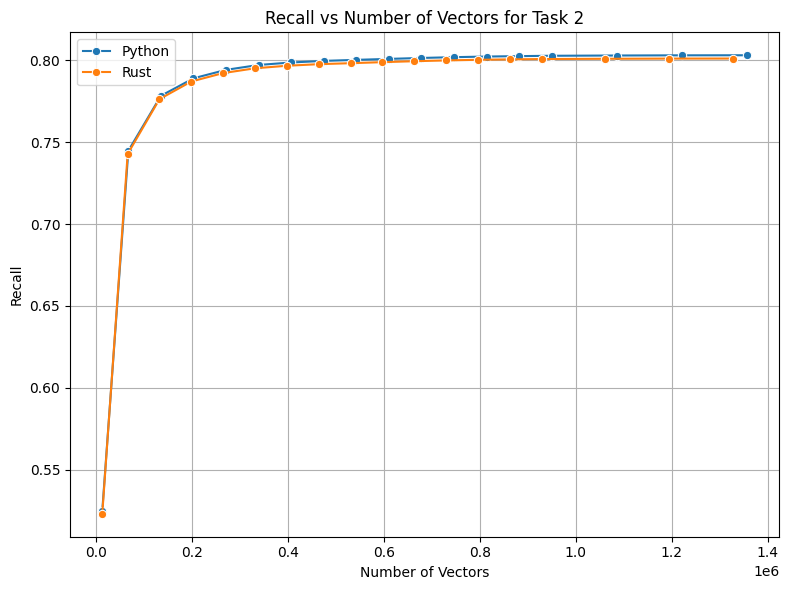

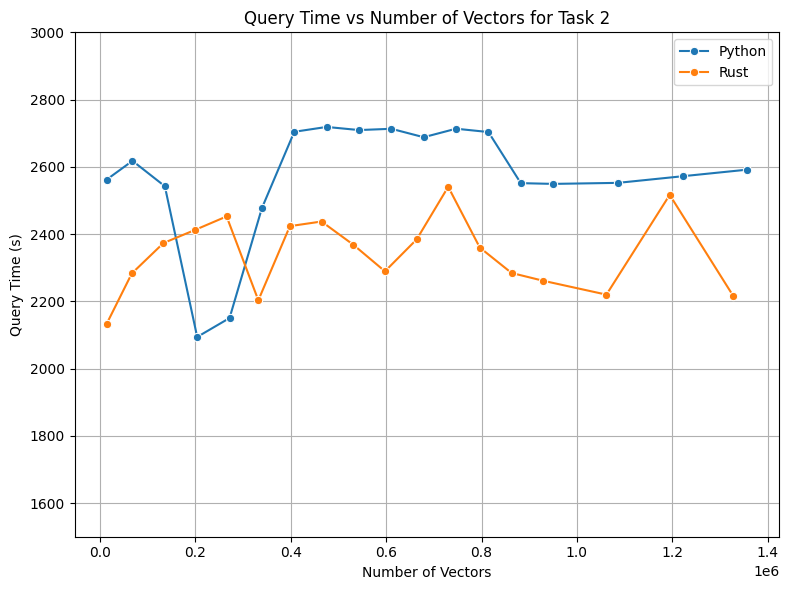

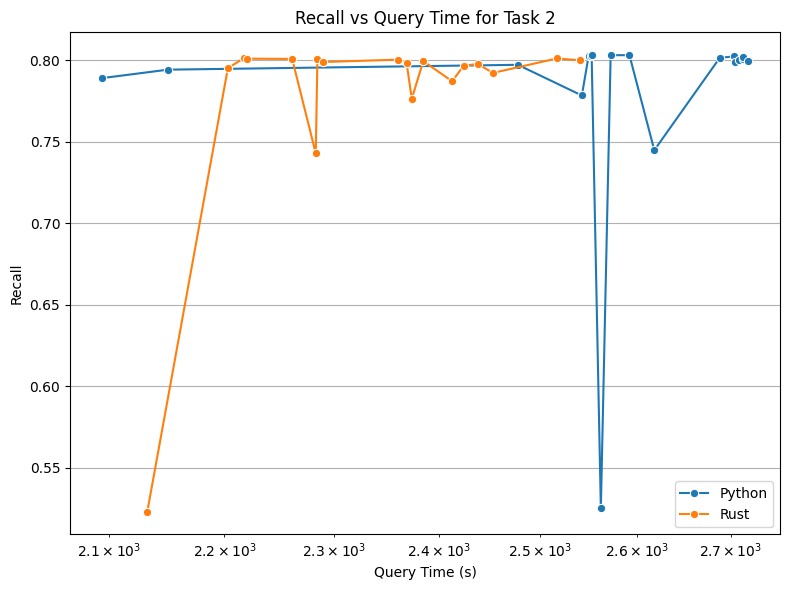

In [50]:
pcsv_task2['memuse'] = '35GB'
rcsv_task2['memuse'] = '35GB'

numeric_metrics = ['kmeanstime', 'encdatabasetime', 'encqueriestime','trainmodeltime', 'buildtime', 'querytime', 'recall']
non_numeric_metrics = ['memuse']

python_means = pcsv_task2[numeric_metrics].mean()
rust_means = rcsv_task2[numeric_metrics].mean()

python_means['memuse'] = pcsv_task2['memuse'].iloc[0]
rust_means['memuse'] = rcsv_task2['memuse'].iloc[0]

# Convert time values from seconds to minutes and seconds format
for metric in ['kmeanstime', 'encdatabasetime', 'encqueriestime','trainmodeltime', 'buildtime', 'querytime']:
    if metric in python_means:
        minutes = int(python_means[metric] // 60)
        seconds = int(python_means[metric] % 60)
        if minutes > 0:
            python_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            python_means[metric] = f"{seconds} seconds"
    if metric in rust_means:
        minutes = int(rust_means[metric] // 60)
        seconds = int(rust_means[metric] % 60)
        if minutes > 0:
            rust_means[metric] = f"{minutes} minutes {seconds} seconds"
        else:
            rust_means[metric] = f"{seconds} seconds"

comparison_df = pd.DataFrame({
    'Python': python_means,
    'Rust': rust_means,
})

comparison_df = comparison_df.round(6)
print("Task 3 Performance Comparison: Python vs Rust")
print(comparison_df)

# Figure 1: Recall vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task2, x='nvectors', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task2, x='nvectors', y='recall', marker='o', label='Rust')
plt.title('Recall vs Number of Vectors for Task 2')
plt.xlabel('Number of Vectors')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task2_recall_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Query Time vs Number of Vectors
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task2, x='nvectors', y='querytime', marker='o', label='Python')
sns.lineplot(data=rcsv_task2, x='nvectors', y='querytime', marker='o', label='Rust')
plt.title('Query Time vs Number of Vectors for Task 2')
plt.xlabel('Number of Vectors')
plt.ylabel('Query Time (s)')
plt.ylim(1500, 3000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('task2_querytime_vs_nvectors.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Recall vs Query Time
plt.figure(figsize=(8, 6))
sns.lineplot(data=pcsv_task2, x='querytime', y='recall', marker='o', label='Python')
sns.lineplot(data=rcsv_task2, x='querytime', y='recall', marker='o', label='Rust')
plt.title('Recall vs Query Time for Task 2')
plt.xlabel('Query Time (s)')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig('task2_recall_vs_querytime.png', dpi=300, bbox_inches='tight')
plt.show()